# Notebook guide

This notebook analyzes ETF inception dates and listing coverage constraints.

## Inputs
- Universe and metadata from the data pipeline stage

## What to verify
- How inception cutoffs change eligible symbols
- Coverage effects over the target analysis horizon

Keep execution sequential so intermediate summaries remain consistent.

# ETF Inception Year Analysis

Analyze when ETFs in our top-500 screened universe were "born" (first data available).

This helps us understand:
- How many ETFs we lose by requiring data before 2016
- The birth distribution across years
- Which specific ETFs are filtered out at each cutoff year

In [1]:
import sys
import pathlib

# Add project root and src/ to path for imports
PROJECT_ROOT = pathlib.Path.cwd().resolve()
for _candidate in [PROJECT_ROOT / "src", PROJECT_ROOT]:
    if str(_candidate) not in sys.path:
        sys.path.insert(0, str(_candidate))

import pandas as pd
import matplotlib.pyplot as plt

from data_pipeline.etf_inception_analysis import (
    load_screen,
    build_inception_summary,
    list_etfs_by_year,
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## 1. Load the Screened Universe

In [2]:
df = load_screen()
print(f"Total ETFs in screened universe: {len(df)}")
print(
    f"Inception years span: {df['inception_year'].min()} to {df['inception_year'].max()}"
)
df.head(10)

Total ETFs in screened universe: 500
Inception years span: 2000 to 2025


,ticker,vol_2020,vol_2021,vol_2022,vol_2023,vol_2024,vol_2025,vol_combined,start_date,inception_year
0,TQQQ,7.103671e+10,3.381874e+10,8.501228e+10,6.203474e+10,2.784458e+10,3.364312e+10,3.133902e+11,2010-02-11,2010
1,SPY,2.699301e+10,1.537053e+10,1.883205e+10,1.624966e+10,1.052750e+10,1.310804e+10,1.010808e+11,2000-01-03,2000
2,SOXL,4.864822e+09,3.347483e+09,1.802757e+10,1.702194e+10,1.754132e+10,2.855812e+10,8.936126e+10,2010-03-11,2010
3,XLF,1.781922e+10,1.403332e+10,1.432466e+10,1.121362e+10,9.548826e+09,9.635013e+09,7.657466e+10,2000-01-03,2000
4,XLE,1.807965e+10,1.717596e+10,1.646601e+10,9.502403e+09,6.552289e+09,7.121843e+09,7.489815e+10,2000-01-03,2000
5,QQQ,1.000872e+10,8.855483e+09,1.357713e+10,1.016846e+10,6.998696e+09,8.778344e+09,5.838684e+10,2000-01-03,2000
6,EEM,1.510159e+10,1.023881e+10,1.190259e+10,7.200327e+09,6.241623e+09,5.706848e+09,5.639178e+10,2003-04-14,2003
7,HYG,9.232246e+09,6.827820e+09,1.115122e+10,1.038581e+10,8.742890e+09,9.266675e+09,5.560666e+10,2007-04-11,2007
8,TSLL,0.000000e+00,0.000000e+00,3.336378e+08,4.121303e+09,1.167644e+10,3.878273e+10,5.491411e+10,2022-08-09,2022
9,SOXS,2.919829e+06,3.374394e+07,3.637149e+08,1.563730e+09,9.692948e+09,4.076937e+10,5.242643e+10,2010-03-11,2010


## 2. Births per Year Summary

In [3]:
summary = build_inception_summary(df)
summary

,inception_year,count,cumulative,pct,cumulative_pct
0,2000,25,25,5.0,5.0
1,2001,7,32,1.4,6.4
2,2002,8,40,1.6,8.0
3,2003,6,46,1.2,9.2
4,2004,25,71,5.0,14.2
5,2005,19,90,3.8,18.0
6,2006,26,116,5.2,23.2
7,2007,56,172,11.2,34.4
8,2008,26,198,5.2,39.6
9,2009,34,232,6.8,46.4


## 3. Births per Year -- Bar Chart

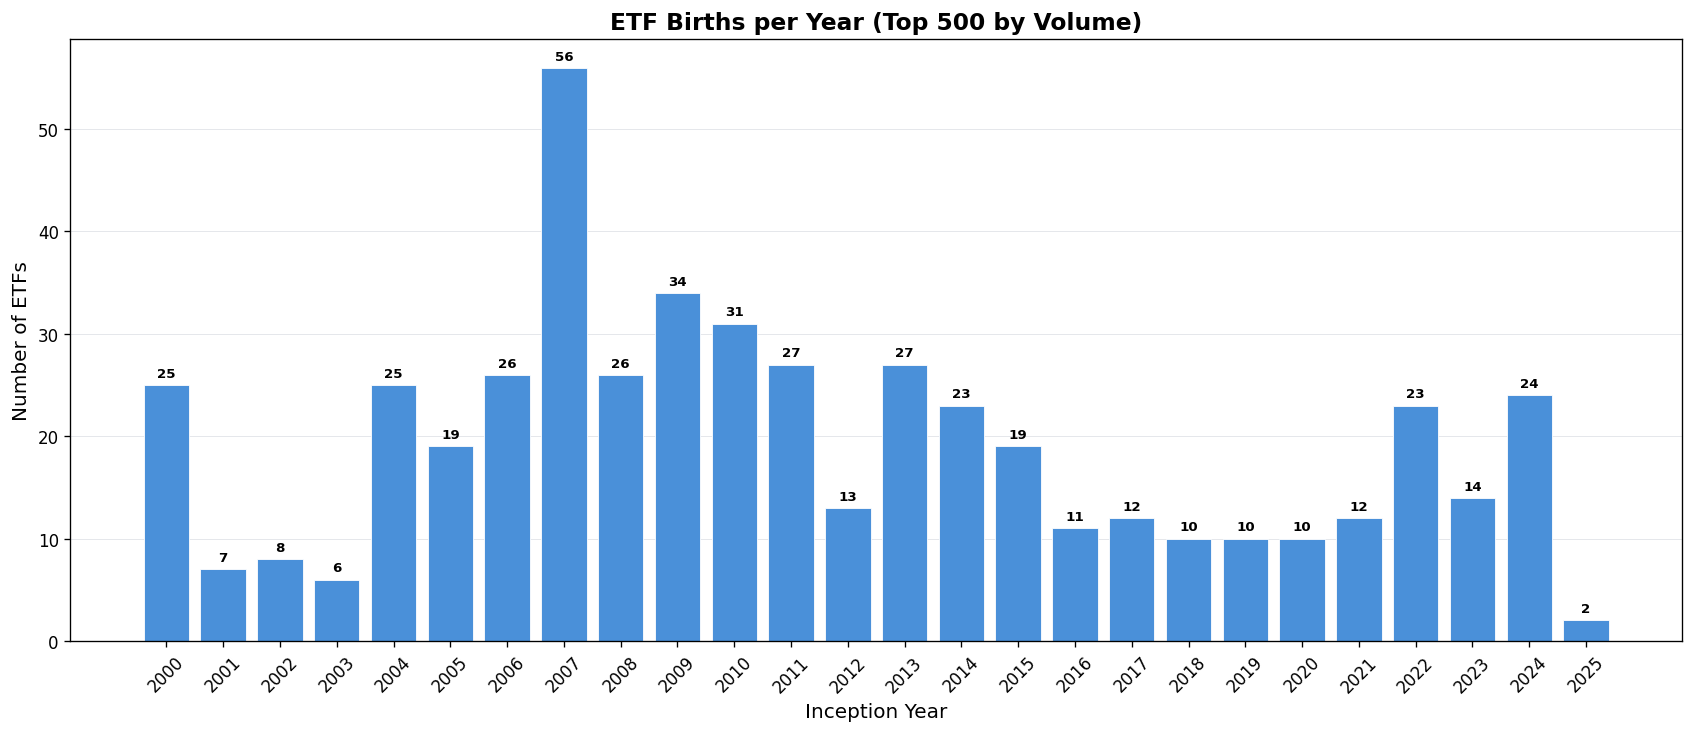

In [4]:
fig, ax = plt.subplots(figsize=(14, 6), constrained_layout=True)

bars = ax.bar(
    summary["inception_year"],
    summary["count"],
    color="#4A90D9",
    edgecolor="white",
    linewidth=0.5,
)

# Count labels on top of each bar
for bar, count in zip(bars, summary["count"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        str(count),
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
    )

ax.set_xlabel("Inception Year", fontsize=12)
ax.set_ylabel("Number of ETFs", fontsize=12)
ax.set_title("ETF Births per Year (Top 500 by Volume)", fontsize=14, fontweight="bold")
ax.grid(axis="y", color="#E5E7EB", linewidth=0.6)
ax.set_axisbelow(True)
ax.set_xticks(summary["inception_year"])
ax.tick_params(axis="x", rotation=45)
plt.show()

## 4. Cumulative Universe Size

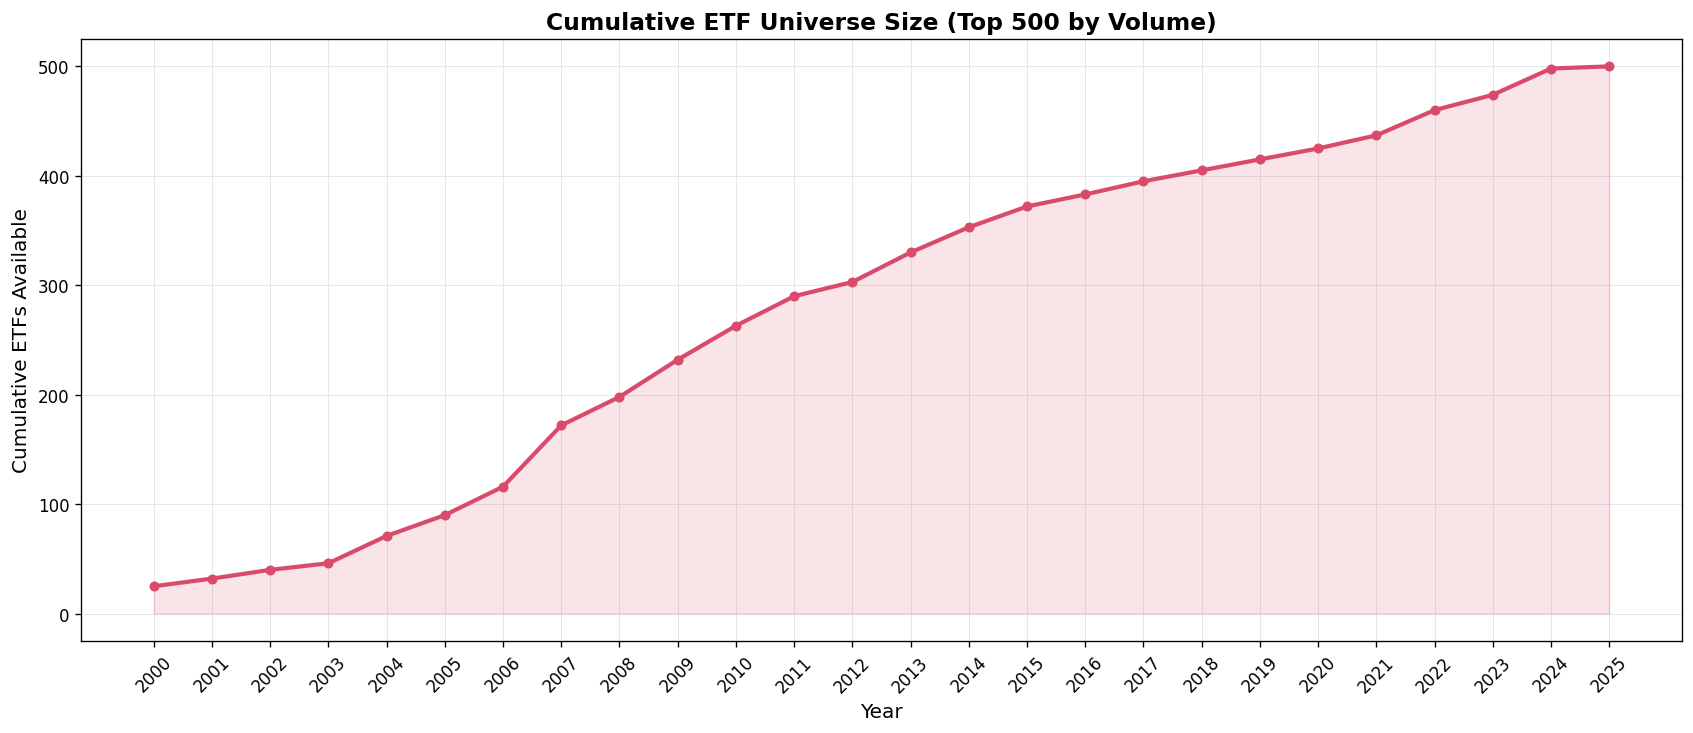

In [5]:
fig, ax = plt.subplots(figsize=(14, 6), constrained_layout=True)

ax.plot(
    summary["inception_year"],
    summary["cumulative"],
    color="#D94A6B",
    linewidth=2.5,
    marker="o",
    markersize=5,
)
ax.fill_between(
    summary["inception_year"], summary["cumulative"], alpha=0.15, color="#D94A6B"
)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Cumulative ETFs Available", fontsize=12)
ax.set_title(
    "Cumulative ETF Universe Size (Top 500 by Volume)", fontsize=14, fontweight="bold"
)
ax.grid(color="#E5E7EB", linewidth=0.6)
ax.set_axisbelow(True)
ax.set_xticks(summary["inception_year"])
ax.tick_params(axis="x", rotation=45)
plt.show()

## 5. Impact of Start-Date Cutoff

How many ETFs survive at each possible cutoff year?

In [6]:
# For each possible cutoff year, count how many ETFs would survive
cutoff_years = list(range(2005, 2025))
cutoff_data = []

for cutoff_year in cutoff_years:
    cutoff_date = pd.Timestamp(f"{cutoff_year}-01-01")
    survivors = df[df["start_date"] <= cutoff_date]
    filtered_out = df[df["start_date"] > cutoff_date]
    cutoff_data.append(
        {
            "cutoff_year": cutoff_year,
            "survivors": len(survivors),
            "filtered_out": len(filtered_out),
            "survival_pct": len(survivors) / len(df) * 100,
        }
    )

cutoff_df = pd.DataFrame(cutoff_data)
cutoff_df

,cutoff_year,survivors,filtered_out,survival_pct
0,2005,71,429,14.2
1,2006,90,410,18.0
2,2007,116,384,23.2
3,2008,172,328,34.4
4,2009,198,302,39.6
5,2010,232,268,46.4
6,2011,263,237,52.6
7,2012,290,210,58.0
8,2013,303,197,60.6
9,2014,330,170,66.0


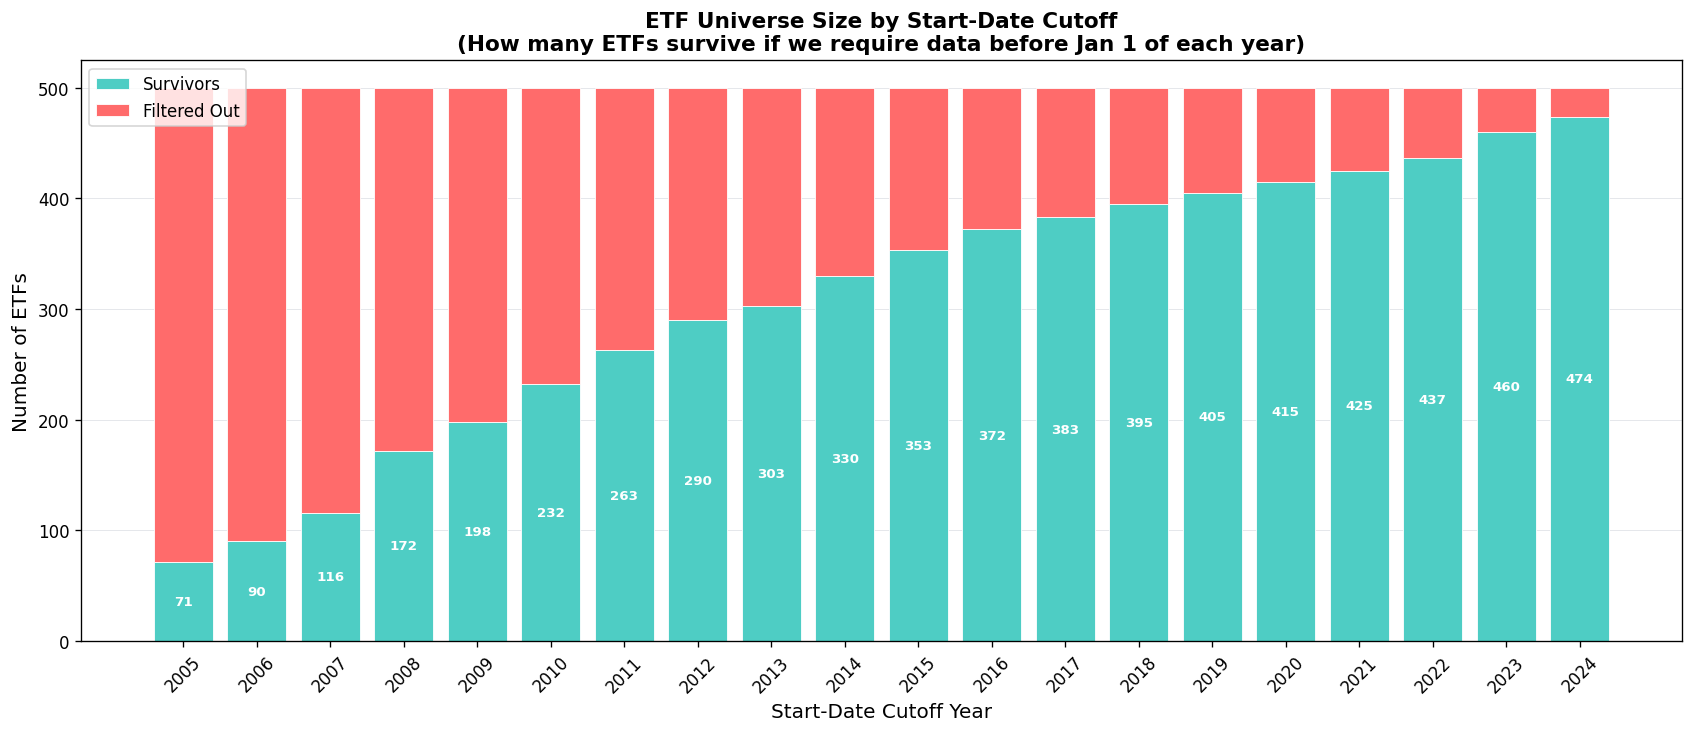

In [7]:
# Plot cutoff sensitivity
fig, ax1 = plt.subplots(figsize=(14, 6), constrained_layout=True)

bars = ax1.bar(
    cutoff_df["cutoff_year"],
    cutoff_df["survivors"],
    color="#4ECDC4",
    edgecolor="white",
    linewidth=0.5,
    label="Survivors",
)

ax1.bar(
    cutoff_df["cutoff_year"],
    cutoff_df["filtered_out"],
    bottom=cutoff_df["survivors"],
    color="#FF6B6B",
    edgecolor="white",
    linewidth=0.5,
    label="Filtered Out",
)

# Labels on the survivors bars
for bar, surv in zip(bars, cutoff_df["survivors"]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        surv / 2,
        str(surv),
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        color="white",
    )

ax1.set_xlabel("Start-Date Cutoff Year", fontsize=12)
ax1.set_ylabel("Number of ETFs", fontsize=12)
ax1.set_title(
    "ETF Universe Size by Start-Date Cutoff\n"
    "(How many ETFs survive if we require data before Jan 1 of each year)",
    fontsize=13,
    fontweight="bold",
)
ax1.legend(fontsize=10)
ax1.set_xticks(cutoff_df["cutoff_year"])
ax1.tick_params(axis="x", rotation=45)
ax1.grid(axis="y", color="#E5E7EB", linewidth=0.6)
ax1.set_axisbelow(True)
plt.show()

## 6. ETF Tickers by Inception Year

Sorted by combined volume within each year.

In [8]:
by_year = list_etfs_by_year(df)

for year, tickers in by_year.items():
    preview = ", ".join(tickers[:15])
    suffix = f" + {len(tickers) - 15} more" if len(tickers) > 15 else ""
    print(f"{year} ({len(tickers):3d}): {preview}{suffix}")

2000 ( 25): SPY, XLF, XLE, QQQ, XLU, IWM, XLK, XLP, XLB, XLI, XLV, XLY, EWJ, SMH, EZU + 10 more
2001 (  7): EFA, VTI, IBB, IXC, IWP, OIH, IWS
2002 (  8): TLT, LQD, IEF, SHY, IGV, FEZ, ILF, IWR
2003 (  6): EEM, AGG, RSP, TIP, FVD, DVY
2004 ( 25): FXI, GLD, IJH, EWT, VNQ, EWH, IJR, EWY, EWU, VTV, IYE, VUG, VDE, IVE, EWS + 10 more
2005 ( 19): EWZ, VWO, IAU, IYR, VGK, IVV, EFV, KBE, IVW, XLG, EWL, KIE, EFG, VPL, IYZ + 4 more
2006 ( 26): GDX, SLV, KRE, SSO, QLD, XBI, SH, XOP, USO, PSQ, XRT, QID, XME, ITB, XHB + 11 more
2007 ( 56): HYG, SDS, VEA, JNK, BND, EMB, BIL, PFF, SPLG, UNG, RWM, SPTL, SPDW, VEU, IGSB + 41 more
2008 ( 26): TZA, TNA, SPXL, UCO, PGX, ICLN, ACWI, TBT, SPXS, TECL, ERX, VT, ACWX, FAS, SCO + 11 more
2009 ( 34): SCHF, UPRO, GDXJ, VCIT, SCHG, SPIB, VCSH, SCHB, TMF, VGSH, SGOL, SPSB, VXX, YINN, SCHA + 19 more
2010 ( 31): TQQQ, SOXL, SOXS, PSLV, UDOW, SQQQ, SCHP, VOO, SCHO, AMLP, PHYS, NUGT, SCHR, SDOW, SCHE + 16 more
2011 ( 27): BKLN, SCHD, SVXY, MCHI, KOLD, VXUS, SCHH, SPLV, 

## 7. Post-2016 ETFs We Filter Out

These are the ETFs born after our current 2016-01-01 cutoff, sorted by volume.
Many are leveraged/inverse products or crypto ETFs.

In [9]:
post_2016 = df[df["start_date"] > pd.Timestamp("2016-01-01")].sort_values(
    "vol_combined",
    ascending=False,
)

print(f"ETFs filtered out by 2016 cutoff: {len(post_2016)}")
print()

# Show them grouped by year
for year, group in post_2016.groupby("inception_year"):
    print(f"\n--- {year} ({len(group)} ETFs) ---")
    display(group[["ticker", "vol_combined", "start_date"]].reset_index(drop=True))

ETFs filtered out by 2016 cutoff: 128


--- 2016 (11 ETFs) ---


,ticker,vol_combined,start_date
0,HYLB,4.887289e+09,2016-12-07
1,COWZ,1.976513e+09,2016-12-19
2,ESGE,1.961095e+09,2016-07-20
3,FALN,1.612811e+09,2016-06-17
4,ESGU,1.383275e+09,2016-12-06
5,BOTZ,1.084725e+09,2016-09-13
6,GBIL,9.086798e+08,2016-09-08
7,BSCQ,7.641101e+08,2016-09-16
8,VYMI,6.641288e+08,2016-03-02
9,ESGD,6.497823e+08,2016-06-30



--- 2017 (12 ETFs) ---


,ticker,vol_combined,start_date
0,USHY,1.015807e+10,2017-10-26
1,JPST,6.877567e+09,2017-05-19
2,DFEN,1.588775e+09,2017-05-03
3,EMXC,1.509721e+09,2017-07-26
4,PAVE,1.471520e+09,2017-03-08
5,PFFD,1.179082e+09,2017-09-13
6,FIXD,1.104966e+09,2017-02-15
7,IDEV,1.095036e+09,2017-03-23
8,CALF,1.079961e+09,2017-06-19
9,BAR,1.001102e+09,2017-08-31



--- 2018 (10 ETFs) ---


...

,ticker,vol_combined,start_date
0,NVDQ,1.268863e+10,2023-10-19
1,NVDX,5.184555e+09,2023-10-19
2,NVD,4.375483e+09,2023-08-22
3,BITX,4.233480e+09,2023-06-27
4,NVDD,3.552505e+09,2023-09-13
5,TSLT,2.549854e+09,2023-10-19
6,NVDY,2.449572e+09,2023-05-11
7,TSDD,1.782251e+09,2023-08-22
8,TSLZ,1.384209e+09,2023-10-19
9,TSLR,8.730084e+08,2023-08-22



--- 2024 (24 ETFs) ---


,ticker,vol_combined,start_date
0,IBIT,1.971300e+10,2024-01-11
1,MSTZ,1.947404e+10,2024-09-18
2,AMDL,6.501593e+09,2024-03-18
3,ETHU,4.575953e+09,2024-06-04
4,SMST,3.561045e+09,2024-08-21
5,MSTX,3.498498e+09,2024-08-15
6,FBTC,2.487832e+09,2024-01-11
7,ARKB,2.079223e+09,2024-01-11
8,TSLG,1.814527e+09,2024-12-13
9,NVOX,1.720473e+09,2024-12-03



--- 2025 (2 ETFs) ---


,ticker,vol_combined,start_date
0,PLTD,3.072738e+09,2025-01-02
1,FNGU,1.014201e+09,2025-02-20
